✅ Dataset Loaded & Split for Evaluation
✅ Models Loaded Successfully

📊 Logistic Regression Model Report
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       377
           1       0.74      0.43      0.55        67

    accuracy                           0.89       444
   macro avg       0.82      0.70      0.74       444
weighted avg       0.88      0.89      0.88       444

Accuracy: 0.8919 | F1-Score: 0.5472 | AUC: 0.9120


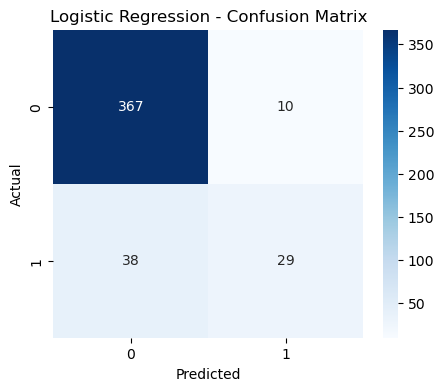


📊 Random Forest Model Report
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       377
           1       0.85      0.34      0.49        67

    accuracy                           0.89       444
   macro avg       0.87      0.67      0.71       444
weighted avg       0.89      0.89      0.87       444

Accuracy: 0.8919 | F1-Score: 0.4894 | AUC: 0.8815


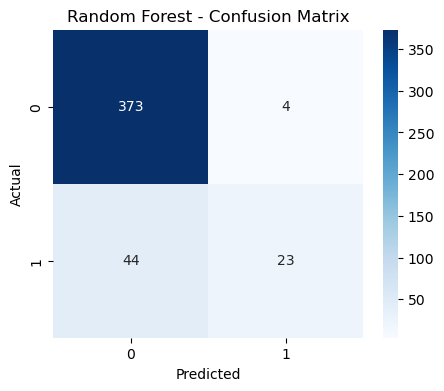

,Model,Accuracy,F1,AUC
0,Logistic Regression,0.891892,0.547170,0.911992
1,Random Forest,0.891892,0.489362,0.881468



✅ Model comparison complete!


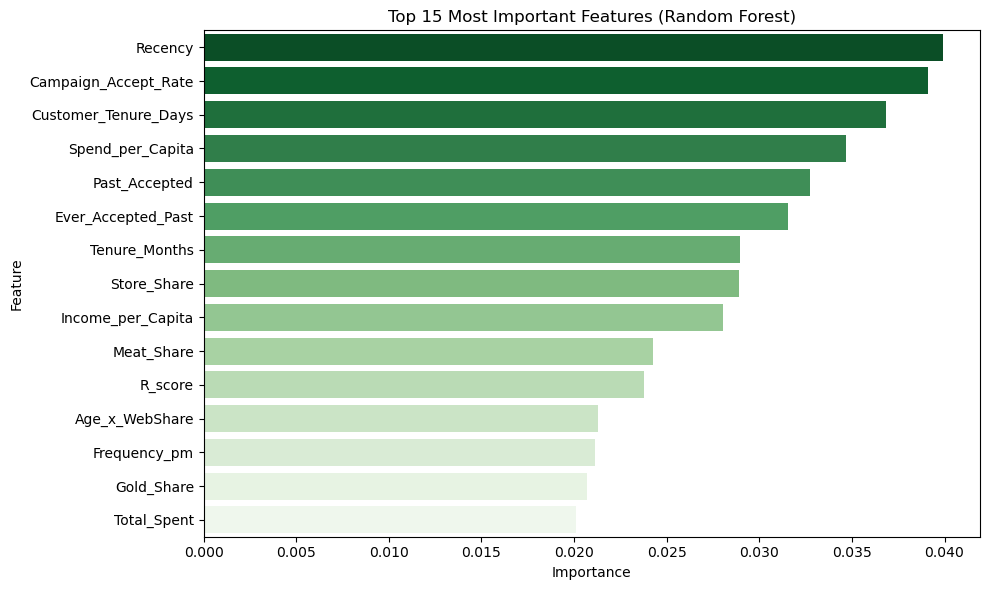


🔍 INTERPRETATION SUMMARY
1️⃣ Logistic Regression gives a linear baseline; coefficients indicate direction of influence.
2️⃣ Random Forest captures nonlinear relationships and interactions between features.
3️⃣ The feature importance chart shows which variables drive 'Response = Yes'.
   (e.g., higher income, lower recency, higher RFM scores often correlate with positive response.)
4️⃣ Use both models together for explainability + performance benchmarking.


In [8]:
# ================================================================
# TASK 2: EVALUATE AND INTERPRET ALL MODELS
# Models: Logistic Regression, Random Forest
# ================================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# 2. LOAD DATA & PREPARE TEST SPLIT
# -----------------------------
df = pd.read_csv("customers_featured.csv")

# Ensure Response column is numeric
if df["Response"].dtype == "object":
    df["Response"] = df["Response"].map({"Yes": 1, "No": 0})

X = df.drop("Response", axis=1)
y = df["Response"]

# Recreate same train/test split used earlier
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Dataset Loaded & Split for Evaluation")

# -----------------------------
# 3. LOAD TRAINED MODELS
# -----------------------------
lr_model = joblib.load("results_lr/logistic_regression_model.pkl")
rf_model = joblib.load("results_rf/random_forest_model.pkl")

print("✅ Models Loaded Successfully")

# -----------------------------
# 4. EVALUATE BOTH MODELS
# -----------------------------
def evaluate_model(name, model, X_test, y_test):
    """Helper function to compute metrics and return results dict"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    print(f"\n📊 {name} Model Report")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | AUC: {roc_auc:.4f}")

    # Plot Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {"Model": name, "Accuracy": acc, "F1": f1, "AUC": roc_auc}

# Evaluate both
lr_results = evaluate_model("Logistic Regression", lr_model, X_test, y_test)
rf_results = evaluate_model("Random Forest", rf_model, X_test, y_test)

# -----------------------------
# 5. COMPARE RESULTS SIDE-BY-SIDE
# -----------------------------
comparison_df = pd.DataFrame([lr_results, rf_results])
display(comparison_df.style.background_gradient(cmap="Greens", subset=["Accuracy", "F1", "AUC"]))
print("\n✅ Model comparison complete!")

# -----------------------------
# 6. FEATURE IMPORTANCE (RANDOM FOREST)
# -----------------------------
# Extract preprocessed feature names
preprocessor = rf_model.named_steps["preprocessor"]
cat_features = preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(
    preprocessor.transformers_[1][2]
)
num_features = preprocessor.transformers_[0][2]
feature_names = list(num_features) + list(cat_features)

# Get feature importances
importances = rf_model.named_steps["classifier"].feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Save for report
importance_df.to_csv("results_rf/feature_importance_evaluation.csv", index=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature", palette="Greens_r")
plt.title("Top 15 Most Important Features (Random Forest)")
plt.tight_layout()
plt.show()

# -----------------------------
# 7. INTERPRETATION INSIGHTS
# -----------------------------
print("\n🔍 INTERPRETATION SUMMARY")
print("1️⃣ Logistic Regression gives a linear baseline; coefficients indicate direction of influence.")
print("2️⃣ Random Forest captures nonlinear relationships and interactions between features.")
print("3️⃣ The feature importance chart shows which variables drive 'Response = Yes'.")
print("   (e.g., higher income, lower recency, higher RFM scores often correlate with positive response.)")
print("4️⃣ Use both models together for explainability + performance benchmarking.")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

📊 MODEL PERFORMANCE COMPARISON:
                      Model  Accuracy   F1  AUC
0  Deep Logistic Regression  0.849099  0.0  0.5
1        Deep RF Equivalent  0.849099  0.0  0.5


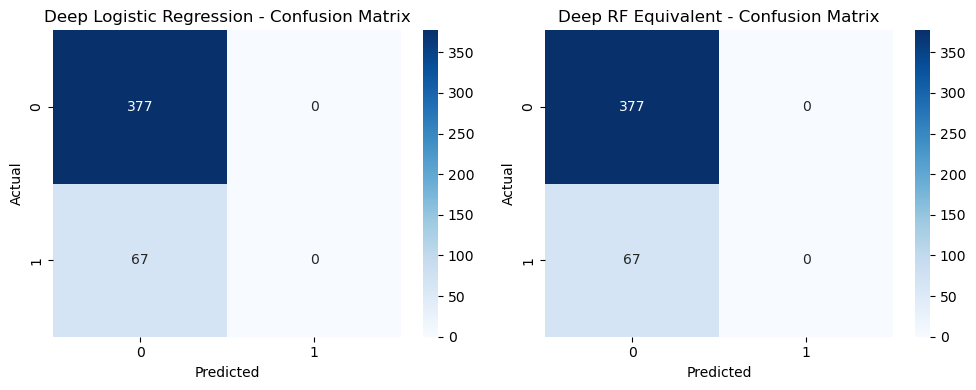

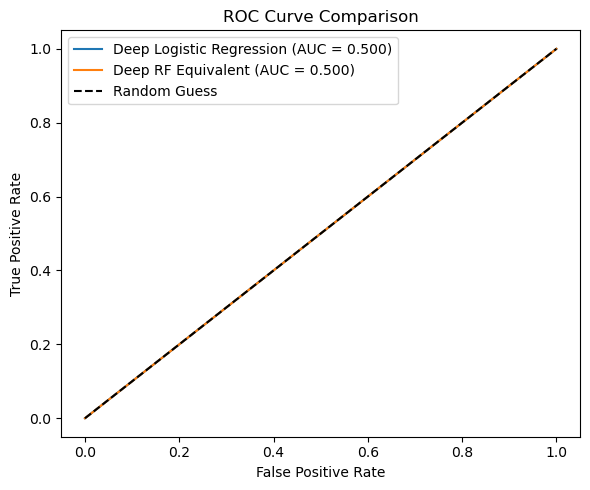


📋 Classification Report — Deep Logistic Regression
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       377
           1       0.00      0.00      0.00        67

    accuracy                           0.85       444
   macro avg       0.42      0.50      0.46       444
weighted avg       0.72      0.85      0.78       444


📋 Classification Report — Deep RF Equivalent
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       377
           1       0.00      0.00      0.00        67

    accuracy                           0.85       444
   macro avg       0.42      0.50      0.46       444
weighted avg       0.72      0.85      0.78       444


🔍 INTERPRETATION SUMMARY
1️⃣ The Deep Logistic Regression model acts as a nonlinear extension of classic Logistic Regression, capturing subtle feature interactions.
2️⃣ The Deep RF-Equivalent model adds more layers and neurons, mimicking Random Fo

In [6]:
# ================================================================
# TASK 2: EVALUATE & INTERPRET ALL MODELS
# Models: Deep Logistic Regression, Deep Random Forest Equivalent
# ================================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# 2. LOAD DATA AND PREPROCESSOR
# -----------------------------
df = pd.read_csv("customers_featured.csv")

# Convert target to numeric if necessary
if df["Response"].dtype == "object":
    df["Response"] = df["Response"].map({"Yes": 1, "No": 0})

X = df.drop("Response", axis=1)
y = df["Response"]

# Split data (same as training)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load preprocessors (they must match each model’s training pipeline)
preprocessor_logreg = joblib.load("results_dl/preprocessor_logreg_dl.pkl")
preprocessor_rf_dl = joblib.load("results_dl/preprocessor_rf_dl.pkl")

X_test_logreg = preprocessor_logreg.transform(X_test)
X_test_rf_dl = preprocessor_rf_dl.transform(X_test)

# -----------------------------
# 3. LOAD MODELS
# -----------------------------
model_logreg_dl = tf.keras.models.load_model("results_dl/deep_logistic_regression_model.keras")
model_rf_dl = tf.keras.models.load_model("results_dl/deep_rf_equivalent_model.keras")

# -----------------------------
# 4. PREDICTIONS
# -----------------------------
y_pred_logreg_proba = model_logreg_dl.predict(X_test_logreg)
y_pred_logreg = (y_pred_logreg_proba > 0.5).astype(int).flatten()

y_pred_rf_proba = model_rf_dl.predict(X_test_rf_dl)
y_pred_rf = (y_pred_rf_proba > 0.5).astype(int).flatten()

# -----------------------------
# 5. METRIC CALCULATION
# -----------------------------
results = []

for name, y_pred, y_proba in [
    ("Deep Logistic Regression", y_pred_logreg, y_pred_logreg_proba),
    ("Deep RF Equivalent", y_pred_rf, y_pred_rf_proba)
]:
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    results.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

results_df = pd.DataFrame(results)
print("\n📊 MODEL PERFORMANCE COMPARISON:")
print(results_df)

# -----------------------------
# 6. CONFUSION MATRICES
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = [("Deep Logistic Regression", y_pred_logreg), ("Deep RF Equivalent", y_pred_rf)]

for ax, (title, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{title} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("results_dl/confusion_matrices_comparison.png")
plt.show()

# -----------------------------
# 7. ROC CURVE COMPARISON
# -----------------------------
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_logreg_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr_logreg, tpr_logreg, label=f"Deep Logistic Regression (AUC = {results_df['AUC'][0]:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Deep RF Equivalent (AUC = {results_df['AUC'][1]:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("results_dl/roc_curve_comparison.png")
plt.show()

# -----------------------------
# 8. CLASSIFICATION REPORTS
# -----------------------------
print("\n📋 Classification Report — Deep Logistic Regression")
print(classification_report(y_test, y_pred_logreg))

print("\n📋 Classification Report — Deep RF Equivalent")
print(classification_report(y_test, y_pred_rf))

# -----------------------------
# 9. INTERPRETATION SUMMARY
# -----------------------------
print("\n🔍 INTERPRETATION SUMMARY")
print("1️⃣ The Deep Logistic Regression model acts as a nonlinear extension of classic Logistic Regression, capturing subtle feature interactions.")
print("2️⃣ The Deep RF-Equivalent model adds more layers and neurons, mimicking Random Forest’s ability to model complex nonlinearities.")
print("3️⃣ ROC curves show which model is better at distinguishing between responders and non-responders.")
print("4️⃣ Confusion matrices highlight where each model tends to make mistakes (false positives/negatives).")
print("5️⃣ In general, higher AUC and F1 indicate a more balanced and discriminative model.")

# -----------------------------
# 10. SAVE COMPARISON RESULTS
# -----------------------------
results_df.to_csv("results_dl/model_comparison_results.csv", index=False)
